# Icosahedral Global Graph - Using `weather-model-graphs`

This notebook shows how to create global spherical graphs using icosahedral meshes via the `weather-model-graphs` API.

1. **Mesh generation** — building a hierarchy of icosahedral meshes
2. **Graph construction** — flat and hierarchical mesh graphs
3. **Grid-to-mesh connectivity** — connecting input grid points to mesh nodes
4. **`create_all_graph_components`** — end-to-end graph creation with the main API

For a deep-dive into how `weather-model-graphs` builds these graphs internally (including the `trimesh` subdivision algorithm, face-adjacency, and barycentric interpolation), see the companion notebook `icosahedral_global_graph_internals.ipynb`.

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import pyproj

In [2]:
from weather_model_graphs.create.mesh.layouts.icosahedral import (
    create_hierarchy_of_icosahedral_meshes,
    create_flat_icosahedral_mesh_graph,
    create_hierarchical_icosahedral_mesh_graph,
    connect_grid_to_mesh,
    lat_lon_to_cartesian,
    cartesian_to_lat_lon,
)

from weather_model_graphs.create import create_all_graph_components

## 1. Generate Icosahedral Mesh Hierarchy

First, let's generate a hierarchy of icosahedral meshes at different refinement levels.

In [3]:
# Generate mesh hierarchy
max_subdivisions = 3
mesh_list = create_hierarchy_of_icosahedral_meshes(max_subdivisions)

# Print statistics for each level
print("Icosahedral Mesh Hierarchy:")
print("-" * 50)
for level, (vertices, faces) in enumerate(mesh_list):
    print(f"Level {level}: {len(vertices):4d} nodes, {len(faces):5d} faces")
print("-" * 50)
print(f"Total nodes across all levels: {sum(len(v) for v, _ in mesh_list)}")

Icosahedral Mesh Hierarchy:
--------------------------------------------------
Level 0:   12 nodes,    20 faces
Level 1:   42 nodes,    80 faces
Level 2:  162 nodes,   320 faces
Level 3:  642 nodes,  1280 faces
--------------------------------------------------
Total nodes across all levels: 858


## 2. Create a Sample Global Grid

Let's create a regular latitude/longitude grid to represent our input data.

In [4]:
# Create a 2.5deg resolution global grid
resolution = 2.5
lats = np.arange(-90, 90.1, resolution)
lons = np.arange(-180, 180.1, resolution)
grid_lat, grid_lon = np.meshgrid(lats, lons, indexing="ij")
grid_lat_lon = np.column_stack([grid_lat.ravel(), grid_lon.ravel()])

print(f"Grid resolution: {resolution}deg")
print(f"Grid dimensions: {len(lats)} latitudes x {len(lons)} longitudes")
print(f"Total grid nodes: {len(grid_lat_lon)}")

Grid resolution: 2.5deg
Grid dimensions: 73 latitudes x 145 longitudes
Total grid nodes: 10585


## 3. Connect Grid to Mesh (G2M)

Now connect each grid point to nearby mesh nodes using radius-based search.

In [5]:
finest_vertices, finest_faces = mesh_list[-1]

# Connect each grid point to nearby mesh nodes
g2m_edges = connect_grid_to_mesh(
    grid_lat_lon,
    finest_vertices,
    finest_faces,
    radius_factor=0.6,  # connection radius relative to max edge length
)

print(f"Grid-to-mesh connections: {g2m_edges.shape[1]}")
print(f"Average connections per grid node: {g2m_edges.shape[1]/len(grid_lat_lon):.2f}")
print(
    f"Average connections per mesh node: {g2m_edges.shape[1]/len(finest_vertices):.2f}"
)

Grid-to-mesh connections: 16617
Average connections per grid node: 1.57
Average connections per mesh node: 25.88


## 4. Create Mesh Graphs

We can create either flat (single-level) or hierarchical (multi-level) mesh graphs.

In [6]:
# Flat mesh graph (single level)
G_flat = create_flat_icosahedral_mesh_graph(subdivisions=3)
print("Flat mesh graph:")
print(f"  Nodes: {len(G_flat.nodes)}")
print(f"  Edges: {len(G_flat.edges)}")
print()

# Hierarchical mesh graph (multiple levels with inter-level connections)
G_hier = create_hierarchical_icosahedral_mesh_graph(max_subdivisions=3)
print("Hierarchical mesh graph:")
print(f"  Total nodes: {len(G_hier.nodes)}")
print(f"  Total edges: {len(G_hier.edges)}")

# Count nodes per level
level_counts = {}
for node, data in G_hier.nodes(data=True):
    level = data.get("level", 0)
    level_counts[level] = level_counts.get(level, 0) + 1

print("\nNodes per level:")
for level in sorted(level_counts.keys()):
    print(f"  Level {level}: {level_counts[level]} nodes")

Flat mesh graph:
  Nodes: 642
  Edges: 3840

Hierarchical mesh graph:
  Total nodes: 858
  Total edges: 8052

Nodes per level:
  Level 0: 12 nodes
  Level 1: 42 nodes
  Level 2: 162 nodes
  Level 3: 642 nodes


## 5. Integration with `create_all_graph_components`

Now let's use the main API to create a complete graph with icosahedral mesh.

In [7]:
# Define geographic CRS (WGS84)
geographic_crs = pyproj.CRS.from_string("EPSG:4326")

# Create complete graph with flat icosahedral mesh
G_complete = create_all_graph_components(
    coords=grid_lat_lon,
    mesh_layout="icosahedral",
    m2m_connectivity="icosahedral",
    m2m_connectivity_kwargs={
        "subdivisions": 3,  # Mesh refinement level
        "hierarchical": False,  # Flat mesh (single level)
        "radius": 1.0,  # Sphere radius
    },
    m2g_connectivity="within_radius",
    g2m_connectivity_kwargs={"rel_max_dist": 0.6},
    m2g_connectivity_kwargs={"rel_max_dist": 0.6},
    coords_crs=geographic_crs,
    graph_crs=geographic_crs,
    g2m_connectivity="within_radius",
)

print("Complete graph statistics:")
print(f"  Total nodes: {len(G_complete.nodes)}")
print(f"  Total edges: {len(G_complete.edges)}")

# Count nodes by type
node_types = {}
for node, data in G_complete.nodes(data=True):
    node_type = data.get("type", "unknown")
    node_types[node_type] = node_types.get(node_type, 0) + 1

print("\nNodes by type:")
for node_type, count in node_types.items():
    print(f"  {node_type}: {count}")

# Count edges by component
edge_components = {}
for u, v, data in G_complete.edges(data=True):
    component = data.get("component", "unknown")
    edge_components[component] = edge_components.get(component, 0) + 1

print("\nEdges by component:")
for component, count in edge_components.items():
    print(f"  {component}: {count}")

2026-03-19 21:59:52.953 | DEBUG    | weather_model_graphs.create.base:create_all_graph_components:140 - Projecting coords from CRS(EPSG:4326) to CRS(EPSG:4326) for graph creation.


query_dist = 0.0988  (longest_edge=0.1646, rel=0.6)
query_dist = 0.0988  (longest_edge=0.1646, rel=0.6)
Complete graph statistics:
  Total nodes: 11227
  Total edges: 37074

Nodes by type:
  mesh: 642
  grid: 10585

Edges by component:
  m2m: 3840
  m2g: 16617
  g2m: 16617


## 6. Hierarchical Mesh Example

Create a graph with hierarchical (multi-level) icosahedral mesh.

In [8]:
# Create hierarchical graph with multiple mesh levels
G_hier_complete = create_all_graph_components(
    coords=grid_lat_lon,
    m2m_connectivity="icosahedral",
    mesh_layout="icosahedral",
    m2m_connectivity_kwargs={
        "max_subdivisions": 3,  # Maximum refinement level
        "hierarchical": True,  # Enable hierarchy
        "radius": 1.0,
    },
    m2g_connectivity="within_radius",
    m2g_connectivity_kwargs={
        "max_dist": 0.5,
    },
    g2m_connectivity="within_radius",
    g2m_connectivity_kwargs={
        "max_dist": 0.5,
    },
    coords_crs=geographic_crs,
    graph_crs=geographic_crs,
)

print("Hierarchical graph statistics:")
print(f"  Total nodes: {len(G_hier_complete.nodes)}")
print(f"  Total edges: {len(G_hier_complete.edges)}")

# Count mesh nodes by level
mesh_levels = {}
for node, data in G_hier_complete.nodes(data=True):
    if data.get("type") == "mesh":
        level = data.get("level", 0)
        mesh_levels[level] = mesh_levels.get(level, 0) + 1

print("\nMesh nodes by level:")
for level in sorted(mesh_levels.keys()):
    print(f"  Level {level}: {mesh_levels[level]} nodes")

2026-03-19 21:59:55.890 | DEBUG    | weather_model_graphs.create.base:create_all_graph_components:140 - Projecting coords from CRS(EPSG:4326) to CRS(EPSG:4326) for graph creation.


Hierarchical graph statistics:
  Total nodes: 11227
  Total edges: 850718

Mesh nodes by level:
  Level None: 642 nodes


## 7. Visualize Graph Components

Let's visualize the different components of our graph.

Plotting graph components...
Plotted 3840 edges for component 'm2m'

Mesh node distribution for component 'm2m':
  Longitude range: [-174.1, 180.0]
  Latitude range: [-90.0, 90.0]


C:\Users\Admin\AppData\Local\Temp\ipykernel_21536\4263223742.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


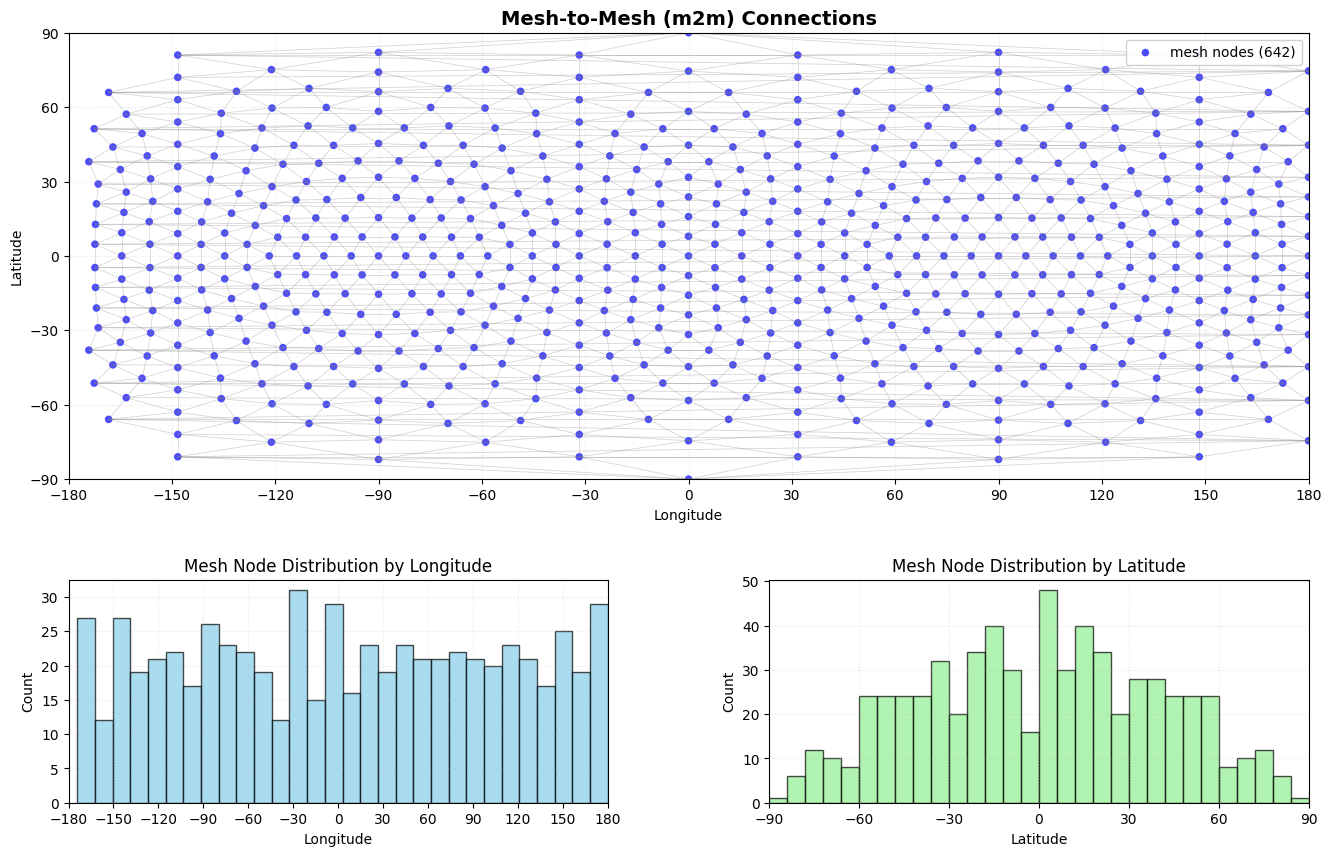

Plotted 16617 edges for component 'g2m'


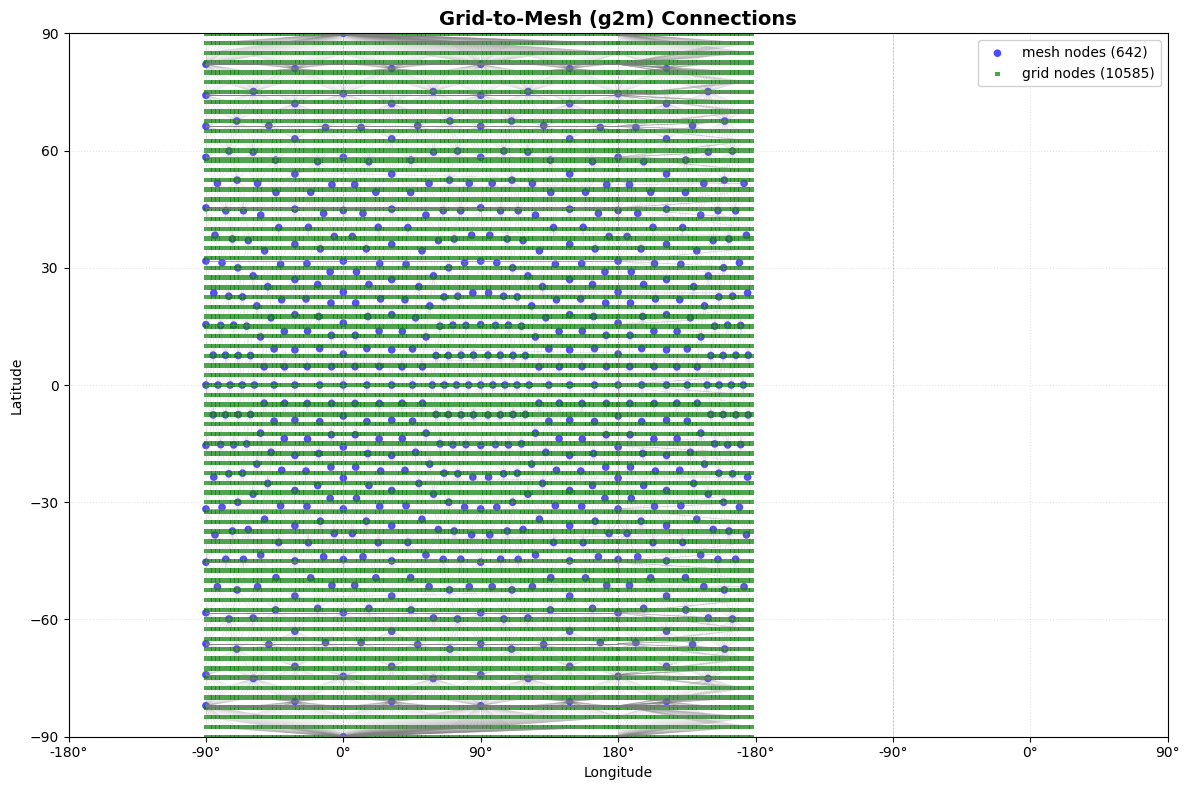

Plotted 16617 edges for component 'm2g'


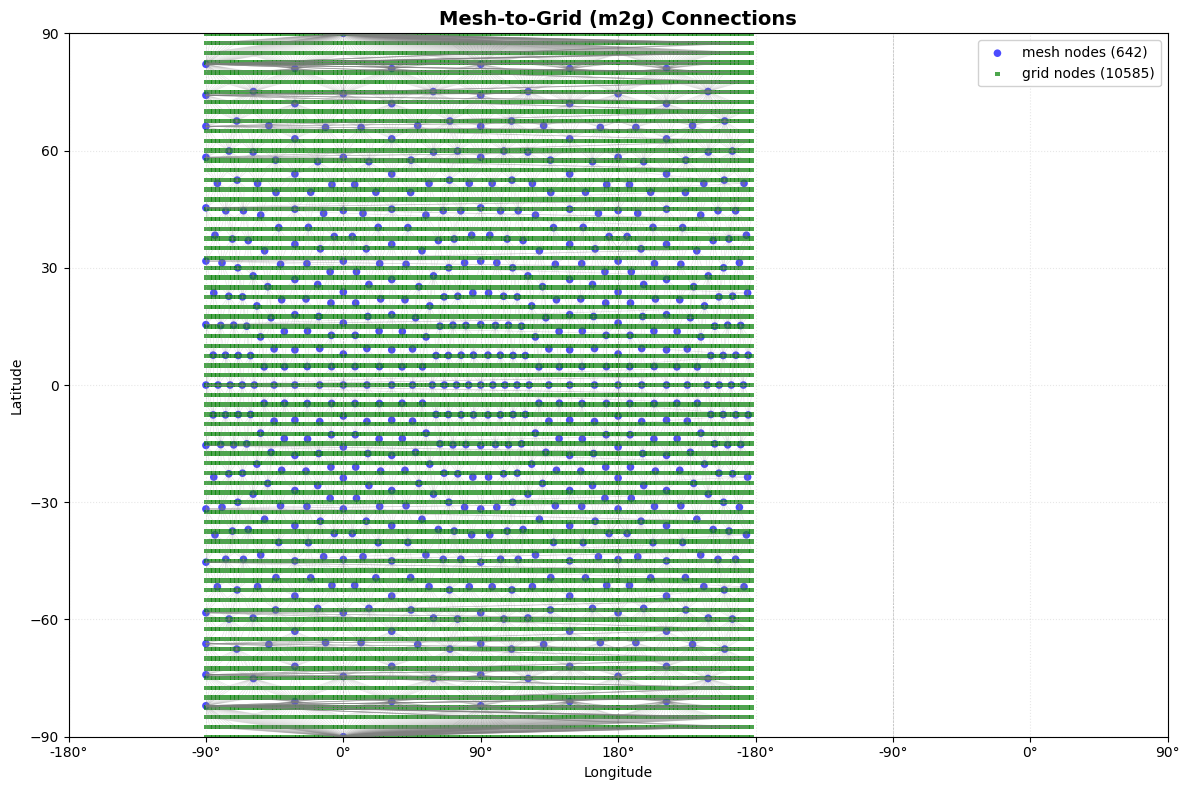

In [9]:
def plot_graph_component(
    G, component_name, title=None, shift_antimeridian=True, show_distribution=False
):
    # Extract subgraph for this component
    edges = [
        (u, v) for u, v, d in G.edges(data=True) if d.get("component") == component_name
    ]

    if not edges:
        print(f"No edges found for component '{component_name}'")
        return

    G_sub = G.edge_subgraph(edges).copy()

    # Collect positions for plotting
    pos_2d = {}
    node_types = {}

    # Also collect mesh node positions separately for distribution analysis
    mesh_lons = []
    mesh_lats = []

    for node in G_sub.nodes:
        data = G.nodes[node]

        if "pos3d" in data and data["pos3d"] is not None:
            # Convert 3D cartesian to lat/lon
            pos3d = data["pos3d"]
            if isinstance(pos3d, (list, np.ndarray)) and len(pos3d) == 3:
                lat_lon = cartesian_to_lat_lon(np.array(pos3d).reshape(1, 3))[0]
                lon, lat = lat_lon[1], lat_lon[0]
            else:
                # Fallback to pos if conversion fails
                if "pos" in data and data["pos"] is not None:
                    pos = data["pos"]
                    if len(pos) == 2:
                        lat, lon = pos[0], pos[1]
                    else:
                        continue
                else:
                    continue
        elif "pos" in data and data["pos"] is not None:
            pos = data["pos"]
            if len(pos) == 2:
                lat, lon = pos[0], pos[1]
            elif len(pos) == 3:
                # Try to interpret as lat/lon/altitude
                lat, lon = pos[0], pos[1]
            else:
                continue
        elif "lat" in data and "lon" in data:
            lat, lon = data["lat"], data["lon"]
        else:
            continue

        node_type = data.get("type", "unknown")
        if node_type == "mesh":
            mesh_lons.append(lon)
            mesh_lats.append(lat)

        if shift_antimeridian and lon < -90:
            lon += 360

        pos_2d[node] = (lon, lat)
        node_types[node] = node_type

    if not pos_2d:
        print(f"No valid position data found for nodes in component '{component_name}'")
        return

    if show_distribution and mesh_lons:
        fig = plt.figure(figsize=(16, 10))
        gs = fig.add_gridspec(2, 2, height_ratios=[2, 1], hspace=0.3, wspace=0.3)

        # Main plot
        ax_main = fig.add_subplot(gs[0, :])

        # Distribution plots
        ax_lon = fig.add_subplot(gs[1, 0])
        ax_lat = fig.add_subplot(gs[1, 1])
    else:
        fig, ax_main = plt.subplots(figsize=(12, 8))

    edge_count = 0
    for u, v in G_sub.edges():
        if u in pos_2d and v in pos_2d:
            x_coords = [pos_2d[u][0], pos_2d[v][0]]
            y_coords = [pos_2d[u][1], pos_2d[v][1]]

            if shift_antimeridian:
                if abs(x_coords[0] - x_coords[1]) > 180:
                    # Split the edge into two segments
                    x_mid = 180 if max(x_coords) > 180 else -180
                    y_mid1 = np.interp(x_mid, x_coords, y_coords)
                    y_mid2 = y_mid1

                    # Plot first segment
                    ax_main.plot(
                        [x_coords[0], x_mid],
                        [y_coords[0], y_mid1],
                        "gray",
                        alpha=0.2,
                        linewidth=0.5,
                    )
                    # Plot second segment
                    ax_main.plot(
                        [x_mid, x_coords[1]],
                        [y_mid2, y_coords[1]],
                        "gray",
                        alpha=0.2,
                        linewidth=0.5,
                    )
                else:
                    ax_main.plot(x_coords, y_coords, "gray", alpha=0.2, linewidth=0.5)
            else:
                ax_main.plot(x_coords, y_coords, "gray", alpha=0.2, linewidth=0.5)
            edge_count += 1

    print(f"Plotted {edge_count} edges for component '{component_name}'")

    colors = {"mesh": "blue", "grid": "green", "unknown": "red"}
    markers = {"mesh": "o", "grid": "s", "unknown": "^"}
    sizes = {"mesh": 30, "grid": 10, "unknown": 20}

    for node_type in set(node_types.values()):
        nodes = [n for n in G_sub.nodes if node_types[n] == node_type]
        if nodes:
            x = [pos_2d[n][0] for n in nodes]
            y = [pos_2d[n][1] for n in nodes]

            scatter = ax_main.scatter(
                x,
                y,
                c=colors.get(node_type, "black"),
                marker=markers.get(node_type, "o"),
                s=sizes.get(node_type, 20),
                label=f"{node_type} nodes ({len(nodes)})",
                alpha=0.7,
                edgecolors="none",
            )

    if shift_antimeridian:
        ax_main.set_xlim(-180, 540)  # Show from -180 to +180 (shifted to 540)
        ax_main.axvline(x=0, color="gray", linestyle="--", alpha=0.5, linewidth=0.5)
        ax_main.axvline(x=180, color="gray", linestyle="--", alpha=0.5, linewidth=0.5)
        ax_main.axvline(x=360, color="gray", linestyle="--", alpha=0.5, linewidth=0.5)

        # Custom ticks for shifted coordinates
        ax_main.set_xticks([-180, -90, 0, 90, 180, 270, 360, 450, 540])
        ax_main.set_xticklabels(
            ["-180°", "-90°", "0°", "90°", "180°", "-180°", "-90°", "0°", "90°"]
        )
    else:
        ax_main.set_xlim(-180, 180)
        ax_main.set_xticks(np.arange(-180, 181, 30))

    ax_main.set_ylim(-90, 90)
    ax_main.set_yticks(np.arange(-90, 91, 30))

    ax_main.set_xlabel("Longitude")
    ax_main.set_ylabel("Latitude")
    ax_main.grid(True, alpha=0.3, linestyle=":")

    ax_main.legend(loc="upper right", fontsize=10, framealpha=0.9)

    if title:
        ax_main.set_title(title, fontsize=14, fontweight="bold")
    else:
        ax_main.set_title(
            f"Graph Component: {component_name}", fontsize=14, fontweight="bold"
        )

    if show_distribution and mesh_lons:
        # Print distribution statistics
        print(f"\nMesh node distribution for component '{component_name}':")
        print(f"  Longitude range: [{min(mesh_lons):.1f}, {max(mesh_lons):.1f}]")
        print(f"  Latitude range: [{min(mesh_lats):.1f}, {max(mesh_lats):.1f}]")

        ax_lon.hist(mesh_lons, bins=30, edgecolor="black", color="skyblue", alpha=0.7)
        ax_lon.set_xlabel("Longitude")
        ax_lon.set_ylabel("Count")
        ax_lon.set_title("Mesh Node Distribution by Longitude")
        ax_lon.grid(True, alpha=0.3, linestyle=":")

        if shift_antimeridian:
            ax_lon.set_xlim(-180, 540)
            ax_lon.set_xticks([-180, -90, 0, 90, 180, 270, 360, 450, 540])
            ax_lon.set_xticklabels(
                ["-180°", "-90°", "0°", "90°", "180°", "-180°", "-90°", "0°", "90°"],
                rotation=45,
            )
        else:
            ax_lon.set_xlim(-180, 180)
            ax_lon.set_xticks(np.arange(-180, 181, 30))

        # Latitude histogram
        ax_lat.hist(
            mesh_lats, bins=30, edgecolor="black", color="lightgreen", alpha=0.7
        )
        ax_lat.set_xlabel("Latitude")
        ax_lat.set_ylabel("Count")
        ax_lat.set_title("Mesh Node Distribution by Latitude")
        ax_lat.set_xlim(-90, 90)
        ax_lat.set_xticks(np.arange(-90, 91, 30))
        ax_lat.grid(True, alpha=0.3, linestyle=":")

    plt.tight_layout()
    return fig, ax_main if not show_distribution else fig


print("Plotting graph components...")

# Plot m2m (mesh-to-mesh) without shifting to see original distribution
# Also show distribution to verify mesh node coverage
fig, ax = plot_graph_component(
    G_complete,
    "m2m",
    title="Mesh-to-Mesh (m2m) Connections",
    shift_antimeridian=False,
    show_distribution=True,
)
plt.show()

# Plot g2m (grid-to-mesh) with shifting to see full connectivity
fig, ax = plot_graph_component(
    G_complete,
    "g2m",
    title="Grid-to-Mesh (g2m) Connections",
    shift_antimeridian=True,
    show_distribution=False,
)
plt.show()

# Plot m2g (mesh-to-grid) with shifting to see full connectivity
fig, ax = plot_graph_component(
    G_complete,
    "m2g",
    title="Mesh-to-Grid (m2g) Connections",
    shift_antimeridian=True,
    show_distribution=False,
)
plt.show()

## 8. Save and Load Graph

Finally, let's save our graph for later use.

In [10]:
import pickle
import os

# Create directory for saving graphs
os.makedirs("saved_graphs", exist_ok=True)

# Save the complete graph
with open("saved_graphs/icosahedral_graph.pkl", "wb") as f:
    pickle.dump(G_complete, f)

print("Graph saved to 'saved_graphs/icosahedral_graph.pkl'")

# Load it back
with open("saved_graphs/icosahedral_graph.pkl", "rb") as f:
    G_loaded = pickle.load(f)

print(f"\nLoaded graph: {len(G_loaded.nodes)} nodes, {len(G_loaded.edges)} edges")

Graph saved to 'saved_graphs/icosahedral_graph.pkl'

Loaded graph: 11227 nodes, 37074 edges
